## Error Analysis: Understanding WHY the Model Fails
With `SGDClassifier`, scaled inputs achieve approximately 89% accuracy in MNIST. In a real-world project, the next step is NOT to blindly jump into testing another model, but to **analyze the errors** of the existing one.

The key difference:
- A **metric** (accuracy, F1) gives you a number: it tells you _how well_ the model performs.

- **Error analysis** tells you _where and why_ it fails, making it an actionable diagnosis.

> **Central idea:** First, you understand the cause of the error (bad data, missing feature, model bias, unbalanced class), and _then_ you choose the correct intervention. Often, the solution is cheaper than changing the model: more data, a new feature, or preprocessing.

## 0. Starting point
We recreate the model we work with, `SGDClassifier`, trained on the scaled data.

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))

## 1. Clean Predictions with `cross_val_predict`
To analyze errors, we need predictions. But we DON'T want to touch the test set yet (that's saved for the end of the project). The solution is `cross_val_predict`: it performs cross-validation, but instead of returning a score, it returns the **prediction for each image made when that image was in the validation fold** (that is, when the model did NOT see it during training).

> This is called an `out-of-sample` prediction: each prediction was made on data that the model had not seen, so it's an honest estimate of its actual behavior.

In [2]:
from sklearn.model_selection import cross_val_predict

sgd_clf = SGDClassifier(random_state=42)
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
y_train_pred[:10]

C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array(['3', '0', '4', '1', '9', '2', '1', '3', '1', '4'], dtype='<U1')

## 2. The Confusion Matrix
This is a table that compares **what the model predicted** against **what actually happened**, counting how many times each combination occurred.
It answers a question that accuracy alone cannot: not only _how many times it was correct_ but _when it was incorrect, and in what way it was incorrect_.

How to read it:
- **Rows = actual class** (what the digit truly was).

- **Columns = predicted class** (what the model predicted).

- The **main diagonal** (top-left to bottom-right) represents the correct predictions.

- Everything **outside the diagonal** represents errors, and its position indicates exactly what the model confused with what.

To read a cell: row 5, column 8 means _digits that were actually a 5 but the model predicted an 8._

In [3]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, y_train_pred)
cm

array([[5573,    0,   23,    5,    8,   44,   36,    6,  227,    1],
       [   0, 6398,   37,   24,    4,   43,    4,    7,  214,   11],
       [  29,   25, 5220,   91,   73,   25,   68,   36,  380,   11],
       [  22,   17,  117, 5224,    2,  204,   27,   40,  405,   73],
       [  12,   14,   40,    9, 5181,   12,   34,   25,  351,  164],
       [  26,   15,   29,  165,   53, 4445,   74,   14,  541,   59],
       [  30,   15,   43,    3,   43,   96, 5551,    3,  133,    1],
       [  20,    9,   51,   29,   49,   12,    3, 5680,  200,  212],
       [  18,   64,   47,   89,    3,  124,   25,   10, 5426,   45],
       [  23,   18,   30,   65,  117,   37,    1,  179,  387, 5092]],
      dtype=int64)

Reading that table of raw numbers is difficult. `ConfusionMatrixDisplay` graphs it as a colored heatmap, where the patterns stand out. It doesn't change the information; it just visualizes it and gives you control over how it's normalized.

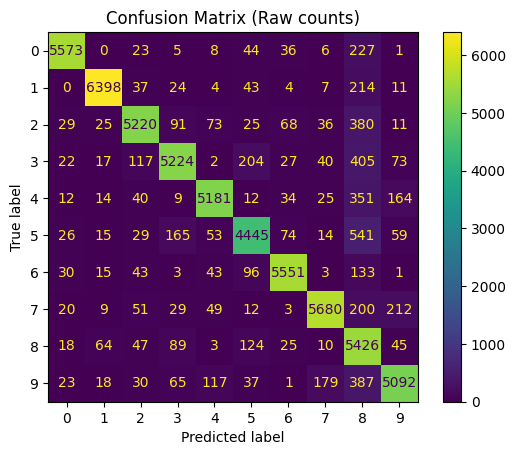

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.title("Confusion Matrix (Raw counts)")
plt.show()

### The Problem with Raw Counts
The 10 classes do NOT have the same number of examples (the dataset doesn't have exactly the same number of each digit). Therefore, a "large" cell might only be large because that class has more examples, not because the model performs better there.

Simple example: if class A has 100 examples with 90 correct predictions (90%) and class B has 1000 with 900 correct predictions (90%), both are equally accurate, but the observer sees "900 >> 90" and believes B is better. The absolute number conflates two things: how well the model predicts and how many examples there were. To separate them, we **normalize**.

## 3. Normalize by row `normalize = true` = RECALL
Divide each cell by the total for that actual class. Now you read "of all the actual 5s, what percentage went to each prediction?" Each row totals 100%.

This division is exactly the formula for **recall**.

$$ \text{Recall} = \frac{TP}{TP + FN} = \text{row total}$$

> **What is recall?**: It's the proportion of true positive cases that the model detected. It answers the question, "Of all the cases that were ACTUALLY a 5, how many did I find?" It measures how much the model misses. It's also called sensitivity or _true positive rate (TPR)_. A low recall means many false negatives.

In a class row: **TP** is the cell on the diagonal, **FN** are all the other cells in that row (the true cases that escaped to another prediction), and **TP + FN** is the entire sum of the row. Therefore, dividing by the total of the row IS calculating the recall.

The argument `values_format = ".0%"` displays percentages without decimals.

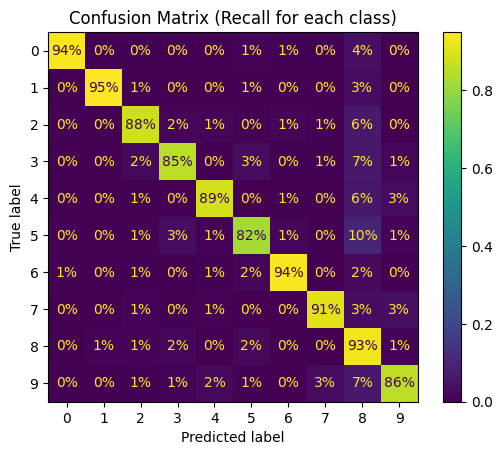

In [5]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")
plt.title("Confusion Matrix (Recall for each class)")
plt.show()

### What it reveals
The diagonal of this matrix is ​​the **recall of each digit.** Looking at it, we see that 5 is usually the least recognized (lowest recall), and that its most common error is confusing it with 8.

The **matrix is ​​not symmetrical**. Confusing A with B is not the same as confusing B with A: the recall of "5 → 8" and that of "8 → 5" are two fractions with the same type of numerator (TP) but completely different denominators (total of actual 5s vs. total of actual 8s), and numerically different. They are two independent calculations that only share the name of the digit pair.
The cell below verifies this with the raw numbers from the 5 and 8 rows.

In [6]:
import numpy as np

class_names = np.unique(y_train) # ['0', '1', ..., '9']
is5 = list(class_names).index('5')
is8 = list(class_names).index('8')

row5 = cm[is5]
row8 = cm[is8]

print(f"row 5 (raw):", row5)
print("TP(5) =", row5[is5])
print("FN(5) total =", row5.sum() - row5[is5])
print("Total row 5 =", row5.sum())
print("Recall(5) = %.3f"% (row5[is5] / row5.sum()))
print(" 5 → 8 = %.3f" % (row5[is8] / row5.sum()), "One of the FN, the largest")
print()
print(f"row 8 (raw):", row8)
print(" 8 → 5 = %.3f" % (row8[is5] / row8.sum()), "different numerator and denominator → NOT symmetric")

row 5 (raw): [  26   15   29  165   53 4445   74   14  541   59]
TP(5) = 4445
FN(5) total = 976
Total row 5 = 5421
Recall(5) = 0.820
 5 → 8 = 0.100 One of the FN, the largest

row 8 (raw): [  18   64   47   89    3  124   25   10 5426   45]
 8 → 5 = 0.021 different numerator and denominator → NOT symmetric


## 4. Hide the successes to see only the errors
The diagonal (the successes) is usually the largest value in each row, and visually overshadows the errors: in a heatmap, the 82% cell shines so brightly that you almost don't notice the 10% next to it. To make the errors compete only with each other, we set **step zero to the successes**.

```python
sample_weight = (y_train_pred != y_train) # True where the model failed, False where it succeeded
```

When converted to `ConfusionMatrixDisplay`, the correct cells count as 0. If we also normalize by row, the new denominator is only the sum of the errors (the FN), without the TP.

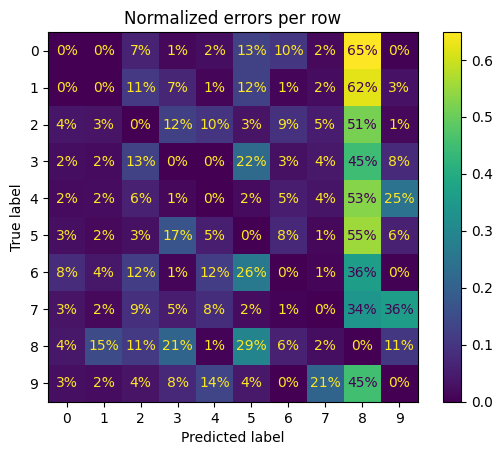

In [7]:
sample_weights = (y_train_pred != y_train)

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weights,
                                        normalize="true", values_format=".0%")
plt.title("Normalized errors per row")
plt.show()

### How to Read and Be Careful with Interpretation

Now each cell answers: _given that the model ALREADY made a mistake with this actual class, which way did it make the mistake_. By removing the slash, the dominant error becomes very clear.

> **Important Trap:** The percentage here is _conditional on there being an error._ If "5→8" appears as ~55%, that means "55% of the errors for 5 were towards 8", NOT "55% of the 5s are confused with 8" (that's still ~10%). The denominator has changed: now it's the total number of errors for that class, not the total for the class.

**The Sink of 8:** Going through the column for 8, almost all the rows point predominantly to it. That is, when the model fails with almost any digit, it tends to predict 8. This pattern, repeated in many independent rows, is the clearest visual sign of the classifier's dominant error.

## 5. Normalize by Column `normalize = "pred"` = Precision
Same operation, but dividing by the total of each **column** instead of each row. Now each column sums to 100%, and the question is reversed: _of everything the model predicted as X, what was it actually_.

This division is the formula for **precision**:
$$\text{Precision} = \frac{TP}{TP + FP} = \text{column total}$$

> **What is precision?**: Of all the times the model said "it's an 8," what proportion actually was? It measures how much you can trust a positive prediction. Low precision means many false positives: things the model called 8s that weren't.

In a class column: **TP** is the diagonal, **FP** are the other cells in that column (things that were NOT in that class but the model said were), and **TP + FP** is the total for the column.

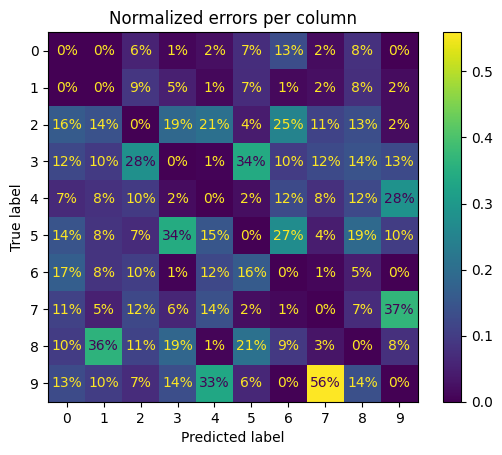

In [10]:
# Normalized errors per column (hiding successes)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weights,
                                        normalize="pred", values_format=".0%")
plt.title("Normalized errors per column")
plt.show()

## Row vs. Column: The Same Cell, Two Different Numbers
The key point is that both normalizations use **the same numerator** (the same confused images) but **different denominators**.

| Perspective | What is normalized? | Question it answers | Related Metric |
|--------------|---------------------|---------------------|----------------|
| **By row (`true`)** | Errors of the **actual** class (FN) | *Where do the mistakes of this class go?* | **Recall** |
| **By column (`pred`)** | Errors of the **predicted** class (FP) | *Where do the wrong predictions come from?* | **Precision** |

That's why the same pair of digits gives different percentages in each view: they are two different questions about the same data. The cell below verifies this by taking the pair (actual 9, predicted 7).

In [12]:
is9 = list(class_names).index('9')
is7 = list(class_names).index('7')

# #9 actual that the model predicted as 7 (same number in both views)
confused_9_as_7 = cm[is9, is7] 

# Total errors in the 9 (denominator per row)
fn_row_9 = cm[is9].sum() - cm[is9, is9]
# Total errors in the 7 prediction (denominator per column)
fp_col_7 = cm[:, is7].sum() - cm[is7, is7]

print(f"Common numerator (real 9 → pred 7): {confused_9_as_7}")

print(
    "By row: %d / %d = %.2f (of the errors of 9, how many were 7)"
    % (confused_9_as_7, fn_row_9, confused_9_as_7 / fn_row_9)
)

print(
    "By column: %d / %d = %.2f (of the errors of 7, how many were 9)"
    % (confused_9_as_7, fp_col_7, confused_9_as_7 / fp_col_7)
)

Common numerator (real 9 → pred 7): 179
By row: 179 / 857 = 0.21 (of the errors of 9, how many were 7)
By column: 179 / 320 = 0.56 (of the errors of 7, how many were 9)


## 6. Inspect Individual Errors
Everything above is aggregated: the matrix says _how many and in which direction_, but it never shows a concrete picture. This step goes down to the level of the data: **look with your own eyes at the images where the model failed**.
It helps answer the _why_, which the matrix alone cannot. By looking at real-world cases, you can distinguish between three explanations:
| What you see | Diagnosis | What to do |
|--------------|-----------|------------|
| Illegible images that even a human would misclassify | **Poor data quality** | Nothing to fix — this is the intrinsic limit of the data |
| Incorrectly labeled samples | **Dirty dataset** | Clean or correct the labels |
| Clear images that the model consistently misclassifies | **Model limitation** | Improve the model, features, or training process |


We will graph 3s and 5s organized as a mini 2x2 confusion matrix. Each block is a Boolean filter that selects a cell.

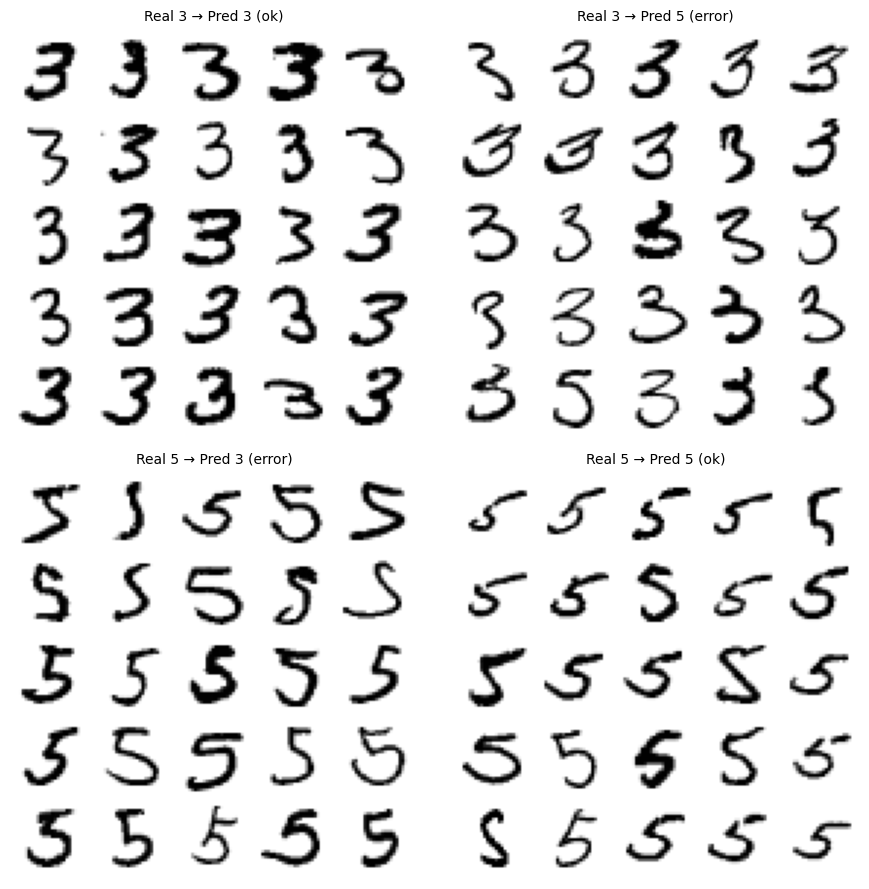

In [14]:
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)] # 3 real → 3 pred (True)
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)] # 3 real → 5 pred (False)
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)] # 5 real → 3 pred (False)
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)] # 5 real → 5 pred (True)

def plot_img(ax, data, title, n=25):
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    rows = int(np.ceil(np.sqrt(n)))
    grid = np.zeros((rows * 28, rows *28))
    for idx in range(min(n, len(data))):
        r, c = divmod(idx, rows)
        grid[r*28:(r+1)*28, c*28:(c+1)*28] = data[idx].reshape(28, 28)
    ax.imshow(grid, cmap='binary')

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
plot_img(axes[0, 0], X_aa, "Real 3 → Pred 3 (ok)")
plot_img(axes[0, 1], X_ab, "Real 3 → Pred 5 (error)")
plot_img(axes[1, 0], X_ba, "Real 5 → Pred 3 (error)")
plot_img(axes[1, 1], X_bb, "Real 5 → Pred 5 (ok)")
plt.tight_layout()
plt.show()